# COE311K Midterm Project (Vishnu Prasad)
## Introduction:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
x = np.arange(1,21)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

plt.scatter(x, y, color='blue', label='Data points')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.show()

<Figure size 640x480 with 1 Axes>

This scatter plot is the dataset provided by the U.S. Bureau of Economic Analysis, showcasing quarterly GDP growth from 2010 to 2023. 20 of the full 56 quarterly data points are included in the given dataset. We will be applying 3 methods to interpolate the rest of the data: cubic spline interpolation, polynomial fitting, and least squares linear regression.

## Part A — Cubic Spline Interpolation

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i + 1]-y[i])/h[i]) - (y[i] - y[i - 1]) / h[i - 1]) # Right-hand side vector
    return A, B, C, D

In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

Condition Number: 7.926094715541833


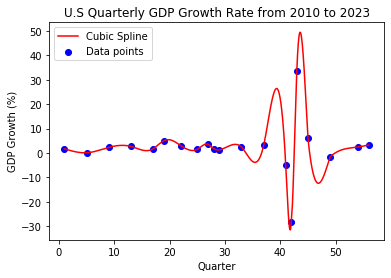

In [5]:
# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

m = len(B)
X = np.zeros((m, m)) 
np.fill_diagonal(X, B) # main diagonal
np.fill_diagonal(X[1:], A) # subdiagonal
np.fill_diagonal(X[:, 1:], C) # superdiagonal
condition = np.linalg.cond(X)
print(f'Condition Number: {condition}')

M = np.zeros(len(x)) # Endpoints are 0 for natural spline
M[1:-1] = thomas_algorithm(A, B, C, D)

x_spline = np.arange(x[0], x[-1], 0.01)
y_spline = evaluate_spline(x, y, M, x_spline)

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_spline, y_spline, color = 'red', label = 'Cubic Spline')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

1. To create the cubic spline interpolation, we first set up a system of equations that relates the second derivatives at each knot in the form of a tridiagonal matrix, using the Thomas algorithm to solve it. For 20 data points, there are 18 unknowns that the Thomas algorithm solves for to satisfy continuity conditions, ensuring that the first and second derivatives of the splines are continuous at the internal points. To satisfy boundary conditions for a natural spline, the second derivatives at the endpoints are set to zero.

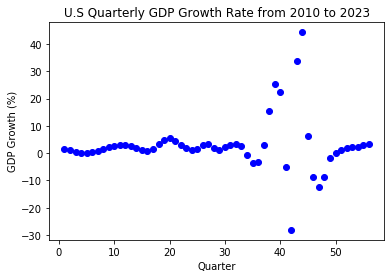

In [6]:
# Interpolating for in-between quarters
x_eval = np.linspace(x[0], x[-1], 56)
y_eval = evaluate_spline(x, y, M, x_eval)

plt.scatter(x_eval, y_eval, color = 'blue', label = 'Data points')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.show()

2. The interpolant does appear visually smooth, but it is questionable whether the interpolant is reasonable close to outlying data points such as 2020 Q2 and 2020 Q3. Since cubic splines are not robust to noise, interpolated GDP growth data near them may not be accurate due to oscillations in the predicted data.

3. Due to significant outliers in 2020 Q2 and 2020 Q3, extreme oscillations occur near this area. Since cubic splines must pass through every point, numerical stability is sacrificed in favor of exact interpolation, leading to Runge's phenomenon, where oscillations appear as the model overfits the data. A weighted least squares model would be more preferable in this scenario, as it will resist the error variance by giving more weight to data points with smaller variances.

## Part B — Polynomial & Least Squares Comparison

In [7]:
def evaluateFit(y, y_pred):
    # Mean Squared Error (MSE)
    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)
    
    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return rmse, r_squared

Condition Number: 18197798.18154116


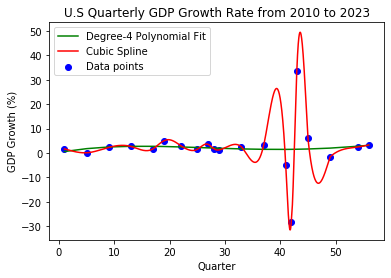

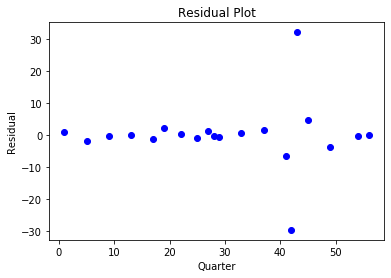

RMSE: 10.031440678677116, R^2: 0.0035410151185396588


In [8]:
degree = 4
V = np.vander(x, N=degree+1, increasing=True)
condition = np.linalg.cond(V)
print(f'Condition Number: {condition}')

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)
y_poly = np.dot(V, coefficients)

plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_poly, color='green', label=f'Degree-4 Polynomial Fit')
plt.plot(x_spline, y_spline, 'red', label = 'Cubic Spline')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

# Residual plot
residuals = y - y_poly
plt.scatter(x, residuals, color = 'blue', label = 'Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

rmse, r_squared = evaluateFit(y, y_poly)
print(f'RMSE: {rmse}, R^2: {r_squared}')

1. The degree-4 polynomial is better at capturing the overall trend while the cubic spline is better at creating a piecewise function that connects every data point in the dataset. Cubic splines excel at interpolating from known data point to known data point, but it comes at the expense of accurate approximation if the data is noisy. The opposite is true for polynomial fitting curves.

In [9]:
def leastSquares(X, Y):
    n = len(X)
    sumXi = np.sum(X)
    sumYi = np.sum(Y)
    sumXiSquared = np.sum(X**2)
    sumXiYi = np.sum(X*Y)
    
    m = (n*sumXiYi - sumXi*sumYi)/(n*sumXiSquared - (sumXi**2))
    c = (sumYi - m*sumXi)/n
    
    return m, c

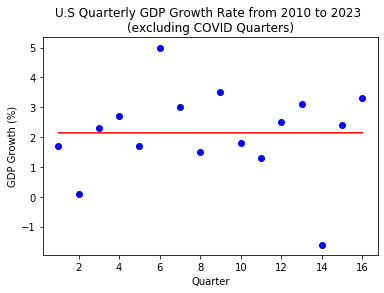

Slope: 0.00014705882352961238


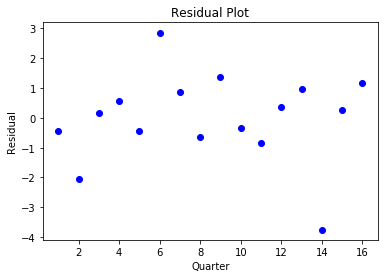

RMSE: 1.4435063137863915, R^2: 2.2054826087636314e-07


In [10]:
# Excluding COVID quarters
x_excluded = np.arange(1,17)
y_excluded = np.concatenate((y[:13], y[17:]))

# Solving least squares model
m, c = leastSquares(x_excluded, y_excluded)
y_linear = m*x_excluded + c

plt.scatter(x_excluded, y_excluded, color = 'blue', label = 'Data points')
plt.plot(x_excluded, y_linear, color = 'red', label = 'Least Squares Line')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023 \n(excluding COVID Quarters)')
plt.show()
print(f'Slope: {m}')

# Residual plot
residuals = y_excluded - y_linear
plt.scatter(x_excluded, residuals, color = 'blue', label = 'Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

rmse, r_squared = evaluateFit(y_excluded, y_linear)
print(f'RMSE: {rmse}, R^2: {r_squared}')

2. Since the R^2 value is near zero, a linear trend for this data does not seem to make sense as the best fit line doesn't explain any of the variance. A linear trend assumes that GDP growth changes at a constant rate over time, which is an oversimplification of the data since GDP growth is affected by numerous external economic factors.

## Part C: — Method Justification

1. Assuming that the known data points are trustworthy, a cubic spline is better at interpolating data points between them. By using low-degree polynomial segments and ensuring continuity in first and second derivatives at interior knots, cubic splines are smoother than high-degree polynomial models by minimizing sharp oscillations (Runge's phenomenon). While both models are sensitive to outliers, an outlier in a polynomial model will skew the entire curve, while an outlier in a cubic spline model will only affect the segments immediately surrounding the outlier. Quantitatively, this is represented by how much larger the condition number of the Vandermonde matrix is compared to the tridiagonal matrix (~7 vs ~10^7) meaning that the cubic spline system is much more numerically stable. Therefore, for interpolation, a cubic spline is smoother, more stable, and more accurate than a polynomial fit.

2. Big O notation is used to represent the time complexity of an algorithm as a function of N number of inputs. Cubic spline interpolation uses the Thomas algorithm which implements forward and backward elimination of a tridiagonal matrix, each with time complexity O(N), resulting in a total time complexity of O(N). Polynomial fitting requires a Vandermonde matrix to be solved using Gaussian elimination, which has a time complexity of O(N^3), resulting in a total time complexity of O(N^3). Therefore, cubic spline interpolation is much more efficient than polynomial fitting in terms of time complexity, so it does not change my final recommendation.

## Conclusion:

We applied 3 methods to fit the GDP growth data: cubic spline interpolation, polynomial fitting, and least squares linear regression. Cubic spline interpolation proved to be the best method at interpolation because it is smooth, passes through every data point, and handles local variation well. However, a cubic spline is not robust to noise as it will pass through any outlier in the dataset, making it less useful for overall trend analysis. On the other hand, polynomial fits and linear regression are least squares methods, which allow them to smooth out noise more effectively than cubic splines. 

In terms of trend analysis, if the data has a visible and global curvature, a polynomial fit will capture the trend best. If not, linear regression might work better if the physics of the system imply a linear relationship. One limitation of polynomial fitting curves is that they are susceptible to overfitting and can cause Runge's phenomenon with higher order polynomials. Additionally, one limitation of linear regression is that it can be an oversimplification for datasets that have multiple external factors. For this dataset, since there is no obvious curvature in the data (disregarding COVID outliers), the linear regression model captured the overall trend better than the polynomial fit, although even the linear model could not explain  much of the variance in the data as there are several economic factors that can affect quarterly GDP growth.